# Polynomial Regression

## Crop Yield Prediction

### Step 1: Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import lineStyles
from sklearn.model_selection import train_test_split

### Step 2: Load Dataset

In [2]:
df = pd.read_csv(r"D:\4th Semester\Machine Learning by Sir  Abdul Aziz\yield_df.csv")
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


### Step 3: Data Preprocessing & EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 1.7 MB


In [4]:
# Dropping a Column 'Unnamed: 0' because it is useless.
df.drop(columns=['Unnamed: 0'], inplace=True)

In [5]:
# Checking Missing values
df.isnull().sum()

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

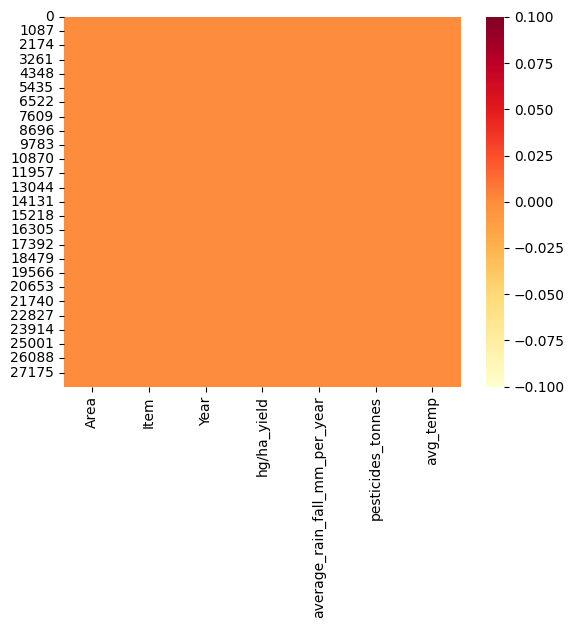

In [6]:
sns.heatmap(df.isnull(),cmap="YlOrRd")
plt.show()

### Step 4: Encoding of Dataset

In [7]:
# Checking String type columns
df.select_dtypes(include="str").columns

Index(['Area', 'Item'], dtype='str')

In [8]:
# Check unique values in Features
df['Area'].unique()

<StringArray>
[       'Albania',        'Algeria',         'Angola',      'Argentina',
        'Armenia',      'Australia',        'Austria',     'Azerbaijan',
        'Bahamas',        'Bahrain',
 ...
     'Tajikistan',       'Thailand',        'Tunisia',         'Turkey',
         'Uganda',        'Ukraine', 'United Kingdom',        'Uruguay',
         'Zambia',       'Zimbabwe']
Length: 101, dtype: str

In [9]:
# Apply Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Area'] = le.fit_transform(df['Area'])

In [10]:
df['Area']

0          0
1          0
2          0
3          0
4          0
        ... 
28237    100
28238    100
28239    100
28240    100
28241    100
Name: Area, Length: 28242, dtype: int64

In [11]:
# Check unique values in Feature 'Item'.
df['Item'].unique()

<StringArray>
[               'Maize',             'Potatoes',          'Rice, paddy',
              'Sorghum',             'Soybeans',                'Wheat',
              'Cassava',       'Sweet potatoes', 'Plantains and others',
                 'Yams']
Length: 10, dtype: str

In [12]:
# Apply Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Item'] = le.fit_transform(df['Item'])
df['Item']

0        1
1        3
2        4
3        5
4        6
        ..
28237    4
28238    5
28239    6
28240    7
28241    8
Name: Item, Length: 28242, dtype: int64

In [13]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,1,1990,36613,1485.0,121.0,16.37
1,0,3,1990,66667,1485.0,121.0,16.37
2,0,4,1990,23333,1485.0,121.0,16.37
3,0,5,1990,12500,1485.0,121.0,16.37
4,0,6,1990,7000,1485.0,121.0,16.37


### Step 5: Normalization

In [14]:
# Balance the Features for better results
from sklearn.preprocessing import MinMaxScaler
m = MinMaxScaler(feature_range=(0,1))
df['Year'] = m.fit_transform(df[['Year']])
df['hg/ha_yield'] = m.fit_transform(df[['hg/ha_yield']])
df['average_rain_fall_mm_per_year'] = m.fit_transform(df[['average_rain_fall_mm_per_year']])
df['pesticides_tonnes'] = m.fit_transform(df[['pesticides_tonnes']])
df['avg_temp'] = m.fit_transform(df[['avg_temp']])

In [15]:
# See the whole dataset
df.head(9)

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,1,0.000000,0.072927,0.449671,0.000329,0.513458
1,0,3,0.000000,0.132872,0.449671,0.000329,0.513458
2,0,4,0.000000,0.046439,0.449671,0.000329,0.513458
3,0,5,0.000000,0.024832,0.449671,0.000329,0.513458
4,0,6,0.000000,0.013862,0.449671,0.000329,0.513458
5,0,8,0.000000,0.060130,0.449671,0.000329,0.513458
6,0,1,0.043478,0.057878,0.449671,0.000329,0.479046
7,0,3,0.043478,0.155113,0.449671,0.000329,0.479046
8,0,4,0.043478,0.056821,0.449671,0.000329,0.479046


### Step 6: Check Linearity of data

<Figure size 1000x500 with 0 Axes>

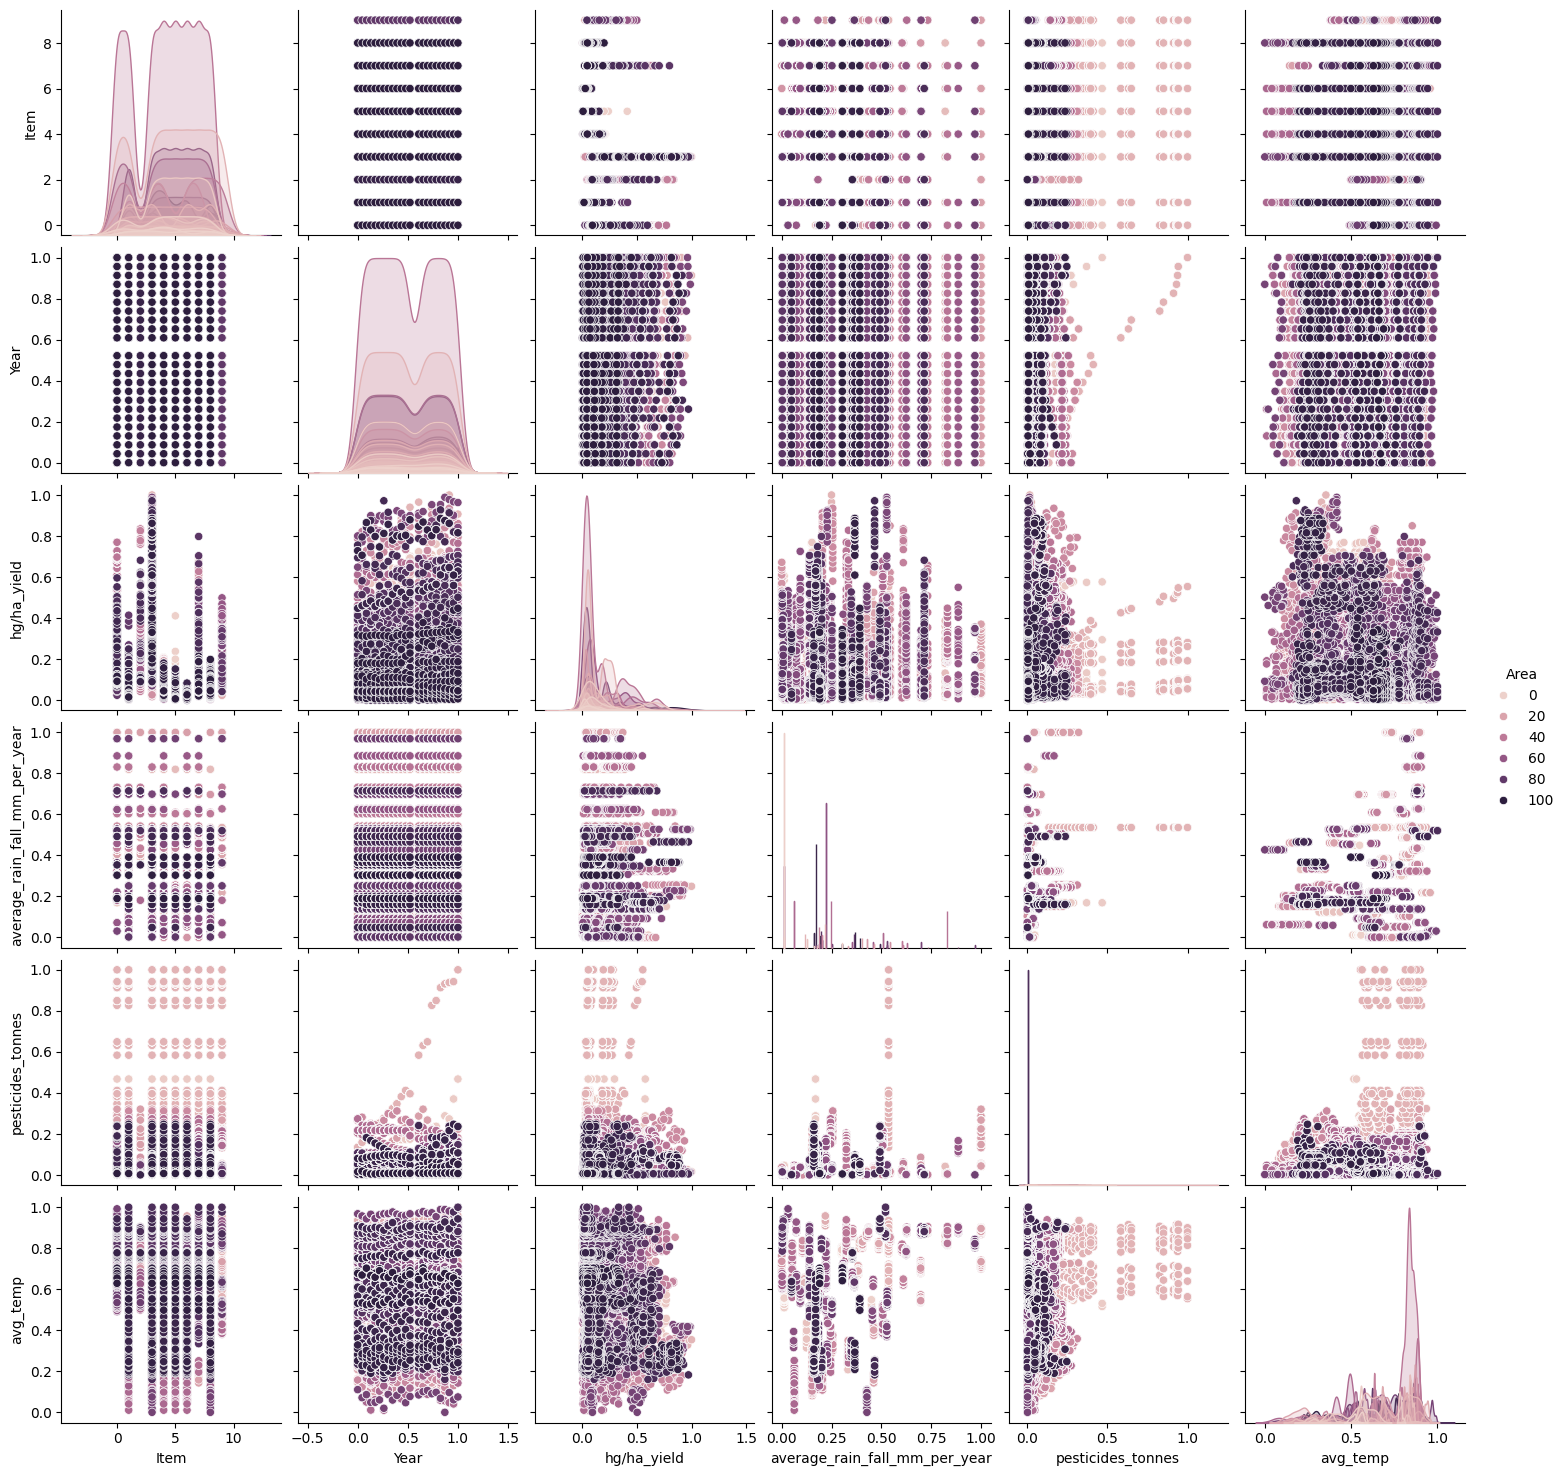

In [16]:
# Make a Graph to see relation visually
plt.figure(figsize=(10,5))
sns.pairplot(data=df,hue="Area",)
plt.show()

### Step 7: Check Correlation

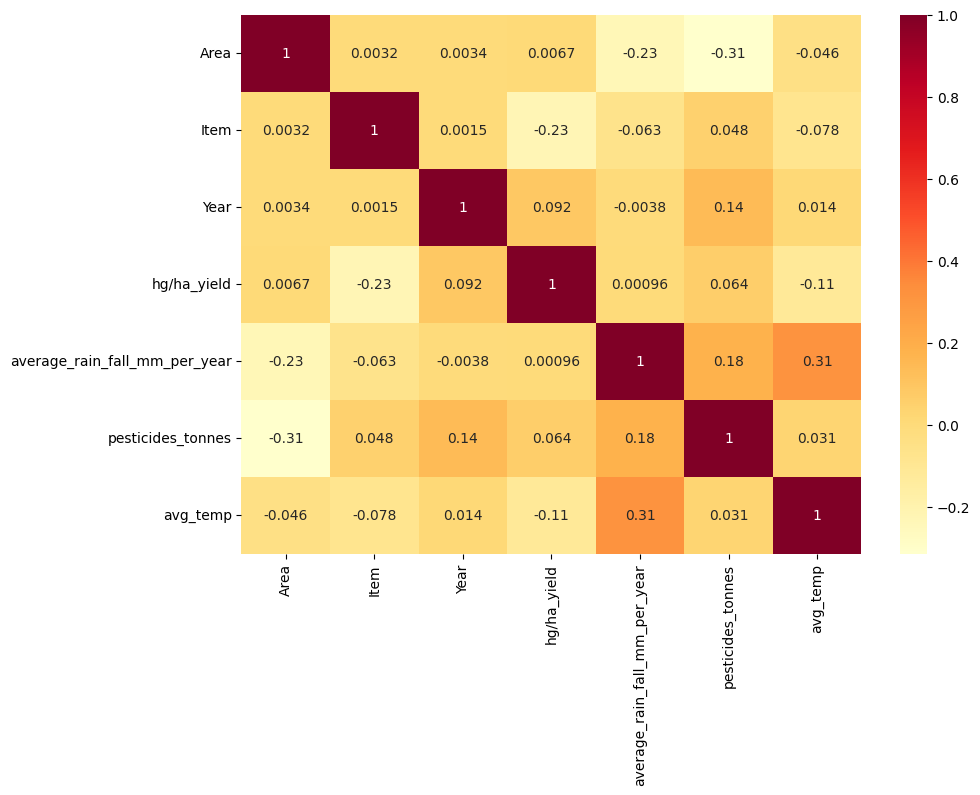

In [17]:
# Checking relation between Columns
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True,cmap="YlOrRd")
plt.show()

### Step 8: Splitting of Data into Training & Testing

In [18]:
X = df[['Area','Item','Year','average_rain_fall_mm_per_year','pesticides_tonnes','avg_temp']]
y = df['hg/ha_yield']
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Step 9: Converting Input Features into Polynomial Form.

In [19]:
from sklearn.preprocessing import PolynomialFeatures
p = PolynomialFeatures(degree=5)
X_poly = p.fit_transform(X_train)
X_test_poly = p.transform(X_test)
X_poly

array([[1.00000000e+00, 1.80000000e+01, 5.00000000e+00, ...,
        2.80269790e-06, 1.01860766e-03, 3.70201000e-01],
       [1.00000000e+00, 4.20000000e+01, 6.00000000e+00, ...,
        2.18421170e-02, 9.51494177e-02, 4.14493325e-01],
       [1.00000000e+00, 8.00000000e+00, 0.00000000e+00, ...,
        1.01090749e-06, 6.40757534e-04, 4.06140247e-01],
       ...,
       [1.00000000e+00, 5.00000000e+00, 3.00000000e+00, ...,
        4.94252825e-04, 6.04223739e-03, 7.38663106e-02],
       [1.00000000e+00, 4.60000000e+01, 7.00000000e+00, ...,
        2.15520574e-03, 3.97401914e-03, 7.32775892e-03],
       [1.00000000e+00, 7.70000000e+01, 7.00000000e+00, ...,
        2.24681954e-04, 2.70199330e-03, 3.24937880e-02]],
      shape=(22593, 462))

In [20]:
X.shape[0]

28242

In [21]:
X_poly.shape[0]

22593

### Step 10: Apply Model

In [22]:
# Apply the same Linear Regression model
from sklearn.linear_model import LinearRegression
le = LinearRegression()
le.fit(X_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 11: Prediction & Check Accuracy

In [23]:
# Check Model Accuracy
le.score(X_test_poly,y_test)*100

49.27392044820543

In [24]:
y_predict = le.predict(X_test_poly)
print(y_predict)

[0.28063104 0.16262077 0.14147988 ... 0.39159776 0.19256163 0.10106899]


### Step 12: Visualization

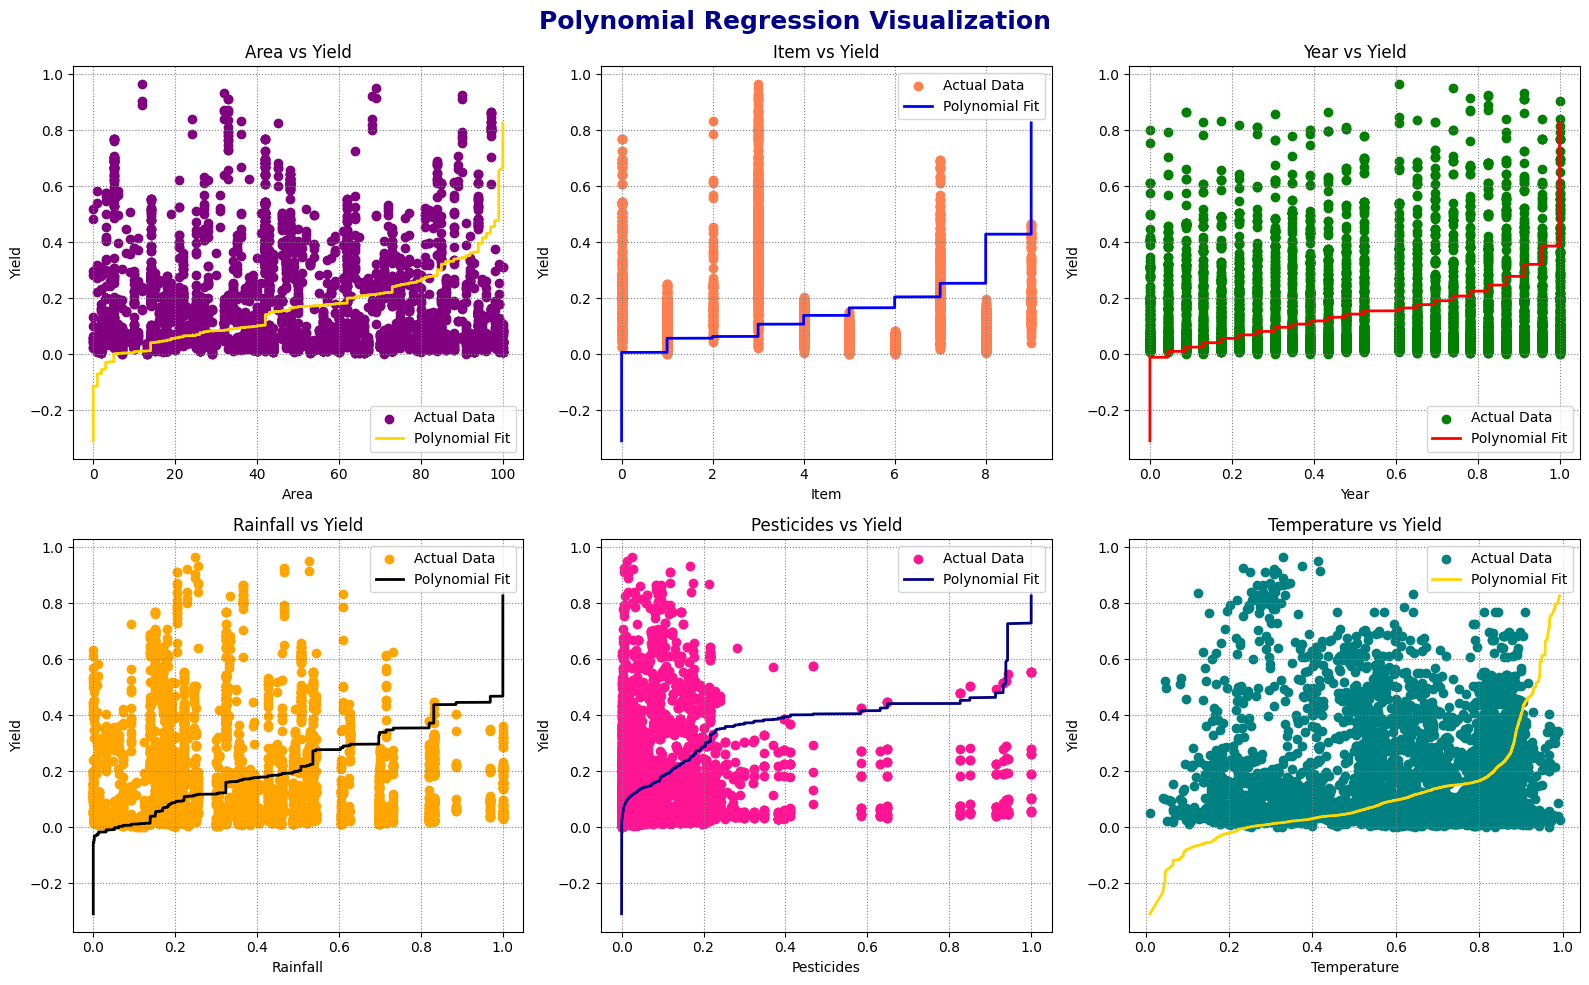

In [25]:
# Every Feature subplots with output Feature to Understand the Polynomial curve.
fig, ax = plt.subplots(2,3, figsize=(16,10))

ax[0,0].scatter(X_test['Area'], y_test,color='purple',label='Actual Data')
ax[0,0].plot(sorted(X_test['Area']),sorted(y_predict),color='gold',linewidth=2,label='Polynomial Fit')
ax[0,0].set_title('Area vs Yield')
ax[0,0].set_xlabel('Area')
ax[0,0].set_ylabel('Yield')
ax[0,0].legend()
ax[0,0].grid(color='grey',linestyle=':')

ax[0,1].scatter(X_test['Item'], y_test,color='coral',label='Actual Data')
ax[0,1].plot(sorted(X_test['Item']),sorted(y_predict),color='blue',linewidth=2,label='Polynomial Fit')
ax[0,1].set_title('Item vs Yield')
ax[0,1].set_xlabel('Item')
ax[0,1].set_ylabel('Yield')
ax[0,1].legend()
ax[0,1].grid(color='grey',linestyle=':')

ax[0,2].scatter(X_test['Year'], y_test,color='green',label='Actual Data')
ax[0,2].plot(sorted(X_test['Year']),sorted(y_predict),color='red',linewidth=2,label='Polynomial Fit')
ax[0,2].set_title('Year vs Yield')
ax[0,2].set_xlabel('Year')
ax[0,2].set_ylabel('Yield')
ax[0,2].legend()
ax[0,2].grid(color='grey',linestyle=':')

ax[1,2].scatter(X_test['avg_temp'], y_test,color='teal',label='Actual Data')
ax[1,2].plot(sorted(X_test['avg_temp']),sorted(y_predict),color='gold',linewidth=2,label='Polynomial Fit')
ax[1,2].set_title('Temperature vs Yield')
ax[1,2].set_xlabel('Temperature')
ax[1,2].set_ylabel('Yield')
ax[1,2].legend()
ax[1,2].grid(color='grey',linestyle=':')

ax[1,0].scatter(X_test['average_rain_fall_mm_per_year'], y_test,color='orange',label='Actual Data')
ax[1,0].plot(sorted(X_test['average_rain_fall_mm_per_year']),sorted(y_predict),color='black',linewidth=2,label='Polynomial Fit')
ax[1,0].set_title('Rainfall vs Yield')
ax[1,0].set_xlabel('Rainfall')
ax[1,0].set_ylabel('Yield')
ax[1,0].legend()
ax[1,0].grid(color='grey',linestyle=':')

ax[1,1].scatter(X_test['pesticides_tonnes'], y_test,color='deeppink',label='Actual Data')
ax[1,1].plot(sorted(X_test['pesticides_tonnes']),sorted(y_predict),color='navy',linewidth=2,label='Polynomial Fit')
ax[1,1].set_title('Pesticides vs Yield')
ax[1,1].set_xlabel('Pesticides')
ax[1,1].set_ylabel('Yield')
ax[1,1].legend()
ax[1,1].grid(color='grey',linestyle=':')

plt.suptitle( 'Polynomial Regression Visualization',fontsize=18,fontweight='bold',color='darkblue')
plt.tight_layout()
plt.show()